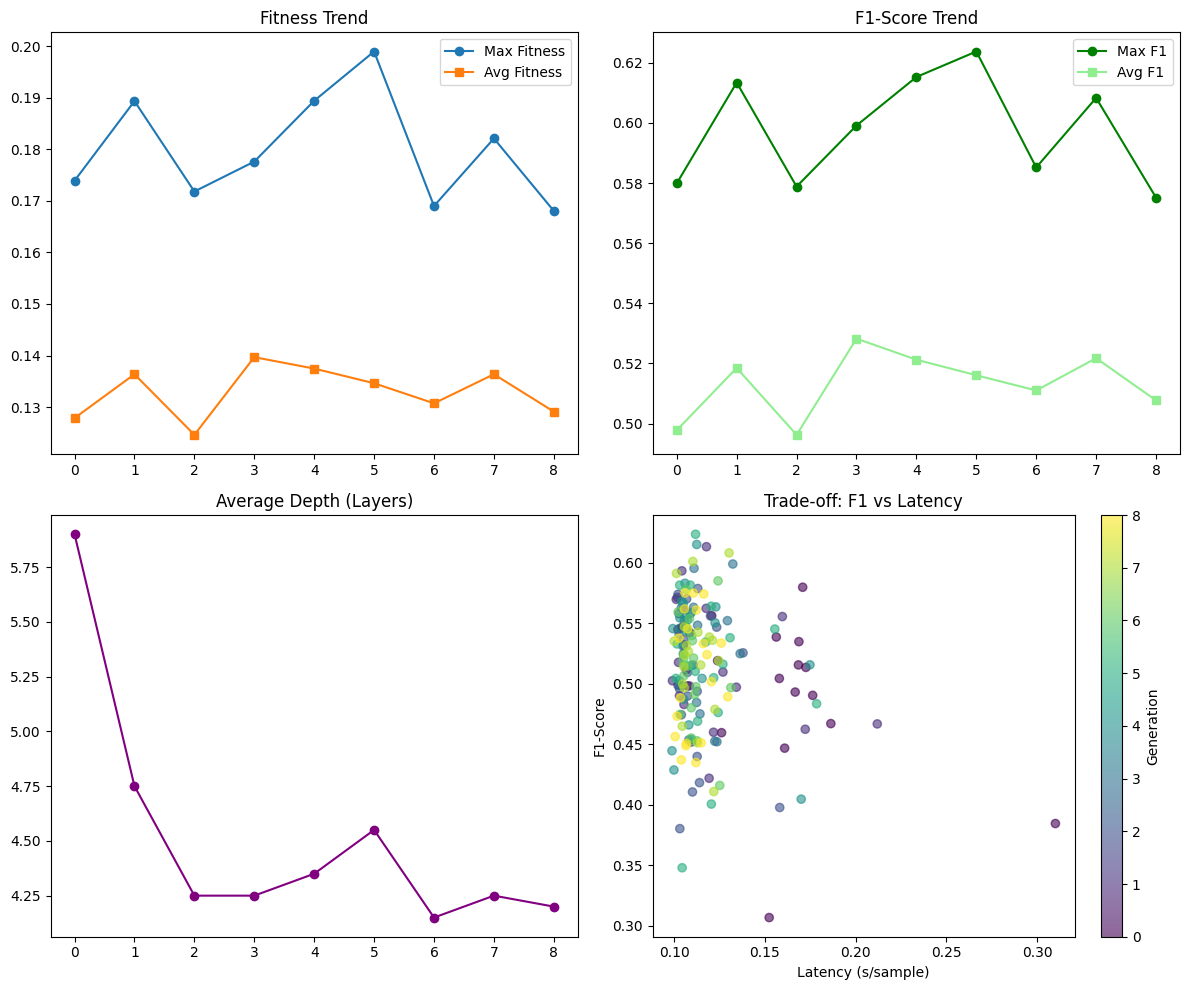

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/agnews_evolution_results1.csv')
gen_agg = df.groupby('generation').agg({
    'fitness': ['max', 'mean'],
    'f1': ['max', 'mean'],
    'latency': 'mean',
    'depth': 'mean'
}).reset_index()

plt.figure(figsize=(12, 10))

# Tendência de Fitness
plt.subplot(2, 2, 1)
plt.plot(gen_agg['generation'], gen_agg['fitness']['max'], label='Max Fitness', marker='o')
plt.plot(gen_agg['generation'], gen_agg['fitness']['mean'], label='Avg Fitness', marker='s')
plt.title('Fitness Trend')
plt.legend()

# Tendência de F1-Score
plt.subplot(2, 2, 2)
plt.plot(gen_agg['generation'], gen_agg['f1']['max'], label='Max F1', marker='o', color='green')
plt.plot(gen_agg['generation'], gen_agg['f1']['mean'], label='Avg F1', marker='s', color='lightgreen')
plt.title('F1-Score Trend')
plt.legend()

# Profundidade Média
plt.subplot(2, 2, 3)
plt.plot(gen_agg['generation'], gen_agg['depth'], label='Avg Depth', marker='o', color='purple')
plt.title('Average Depth (Layers)')

# Trade-off F1 vs Latency
plt.subplot(2, 2, 4)
plt.scatter(df['latency'], df['f1'], c=df['generation'], cmap='viridis', alpha=0.6)
plt.colorbar(label='Generation')
plt.title('Trade-off: F1 vs Latency')
plt.xlabel('Latency (s/sample)')
plt.ylabel('F1-Score')

plt.tight_layout()
plt.show()